# Notebook 05 — Exploratory Data Analysis (EDA)

**Milestone 2, Step 5**

Five analyses as required by the roadmap:
1. **Video duration distribution** — histogram of raw frame counts
2. **Class frequency / imbalance** — videos per sign class
3. **Keypoint quality** — dropout fraction per video group and per category  
   *(Note: signer IDs are recording-session proxy assignments — investigation complete June 2026: signer IDs not publicly available. See Section 3a)*
4. **t-SNE per class** — class-centroid embeddings labelled by sign name
5. **SD / SI split summary**

All figures saved to `data/eda/`.

**Keypoint extraction:** MediaPipe Task API — separate `HandLandmarker` (21 joints × 2 hands)
and `PoseLandmarker` (11 upper-body joints), concatenated to 53 joints total.
This is **not** the legacy MediaPipe Holistic pipeline.

In [11]:
%pip install numpy pandas matplotlib scikit-learn tqdm --quiet

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import pickle
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path('/Users/yamini/Desktop/projects/ISL PROJECT')
DATA_DIR     = PROJECT_ROOT / 'data'
PROC_DIR     = DATA_DIR / 'processed'
EDA_DIR      = DATA_DIR / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
print('Paths OK')

Paths OK


In [13]:
# ── Load metadata + signer IDs ────────────────────────────────────────────────
meta = pd.read_csv(DATA_DIR / 'keypoints_metadata.csv')
meta['category_clean'] = meta['category'].str.strip()

signer_df = pd.read_csv(DATA_DIR / 'signer_ids.csv')   # out_name, signer_id
meta = meta.merge(signer_df[['out_name', 'signer_id']], on='out_name', how='left')

print(f'Total videos : {len(meta)}')
print(f'Signers      : {sorted(meta["signer_id"].dropna().unique().astype(int).tolist())}')
meta[['category', 'sign', 'video_id', 'signer_id', 'n_frames']].head(3)

Total videos : 3652
Signers      : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


,category,sign,video_id,signer_id,n_frames
0,Adjectives,1. loud,MVI_5177,0,56
1,Adjectives,1. loud,MVI_5178,1,64
2,Adjectives,1. loud,MVI_5179,2,66


## 1. Video Duration Distribution

Median frame count, spread, and the long-tail of very long or very short clips.
This motivates the choice of T=64 for temporal resampling.

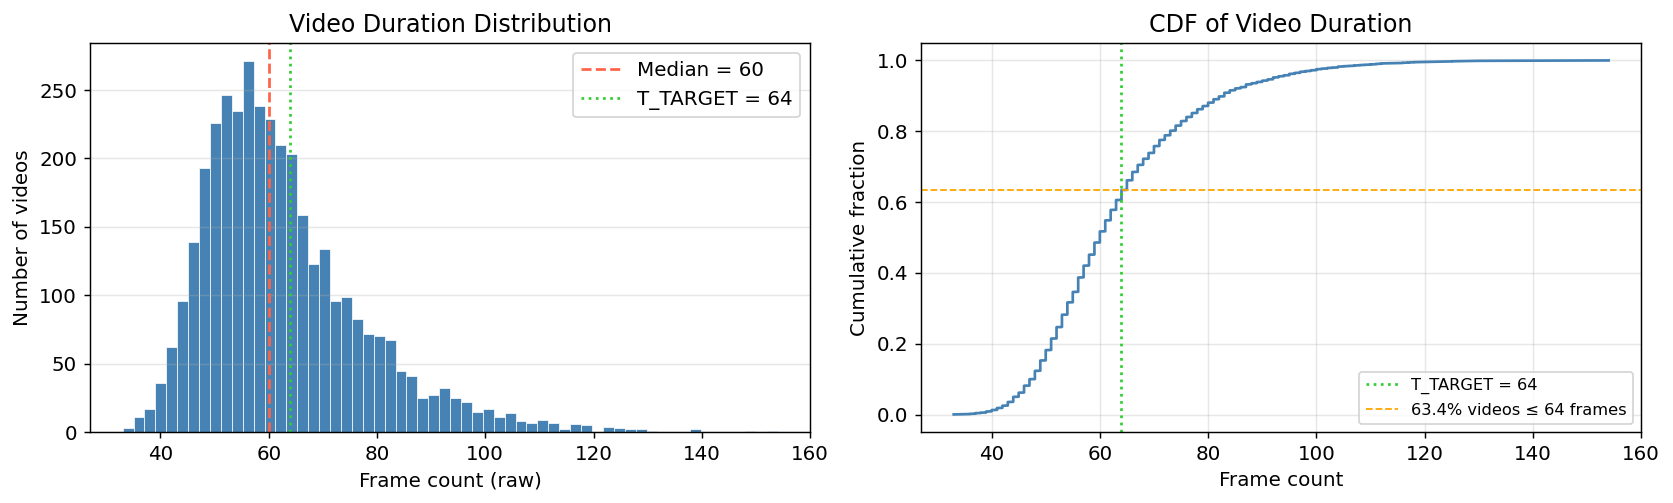

  Count  : 3652
  Min    : 33 frames
  Max    : 154 frames
  Mean   : 63.0 frames
  Median : 60 frames
  Std    : 14.9 frames
  P10    : 48  P90: 83


In [14]:
frames = meta['n_frames']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram
ax = axes[0]
ax.hist(frames, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(frames.median(), color='tomato',    linestyle='--', linewidth=1.5, label=f'Median = {frames.median():.0f}')
ax.axvline(64,              color='limegreen', linestyle=':',  linewidth=1.5, label='T_TARGET = 64')
ax.set_xlabel('Frame count (raw)')
ax.set_ylabel('Number of videos')
ax.set_title('Video Duration Distribution')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Cumulative distribution
ax2 = axes[1]
sorted_frames = np.sort(frames)
cdf = np.arange(1, len(sorted_frames) + 1) / len(sorted_frames)
ax2.plot(sorted_frames, cdf, color='steelblue')
ax2.axvline(64, color='limegreen', linestyle=':', linewidth=1.5, label='T_TARGET = 64')
pct_at_64 = (frames <= 64).mean() * 100
ax2.axhline(pct_at_64 / 100, color='orange', linestyle='--', linewidth=1,
            label=f'{pct_at_64:.1f}% videos ≤ 64 frames')
ax2.set_xlabel('Frame count')
ax2.set_ylabel('Cumulative fraction')
ax2.set_title('CDF of Video Duration')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / 'duration_distribution.png', bbox_inches='tight')
plt.show()

print(f'  Count  : {len(frames)}')
print(f'  Min    : {frames.min()} frames')
print(f'  Max    : {frames.max()} frames')
print(f'  Mean   : {frames.mean():.1f} frames')
print(f'  Median : {frames.median():.0f} frames')
print(f'  Std    : {frames.std():.1f} frames')
print(f'  P10    : {frames.quantile(0.10):.0f}  P90: {frames.quantile(0.90):.0f}')

## 2. Class Frequency / Imbalance Analysis

Check whether any sign class has significantly more or fewer videos than others.
The EDA shows approximately 14 videos per sign class on average (not a clean
multiple of any known signer count, since signer labels are not publicly available).

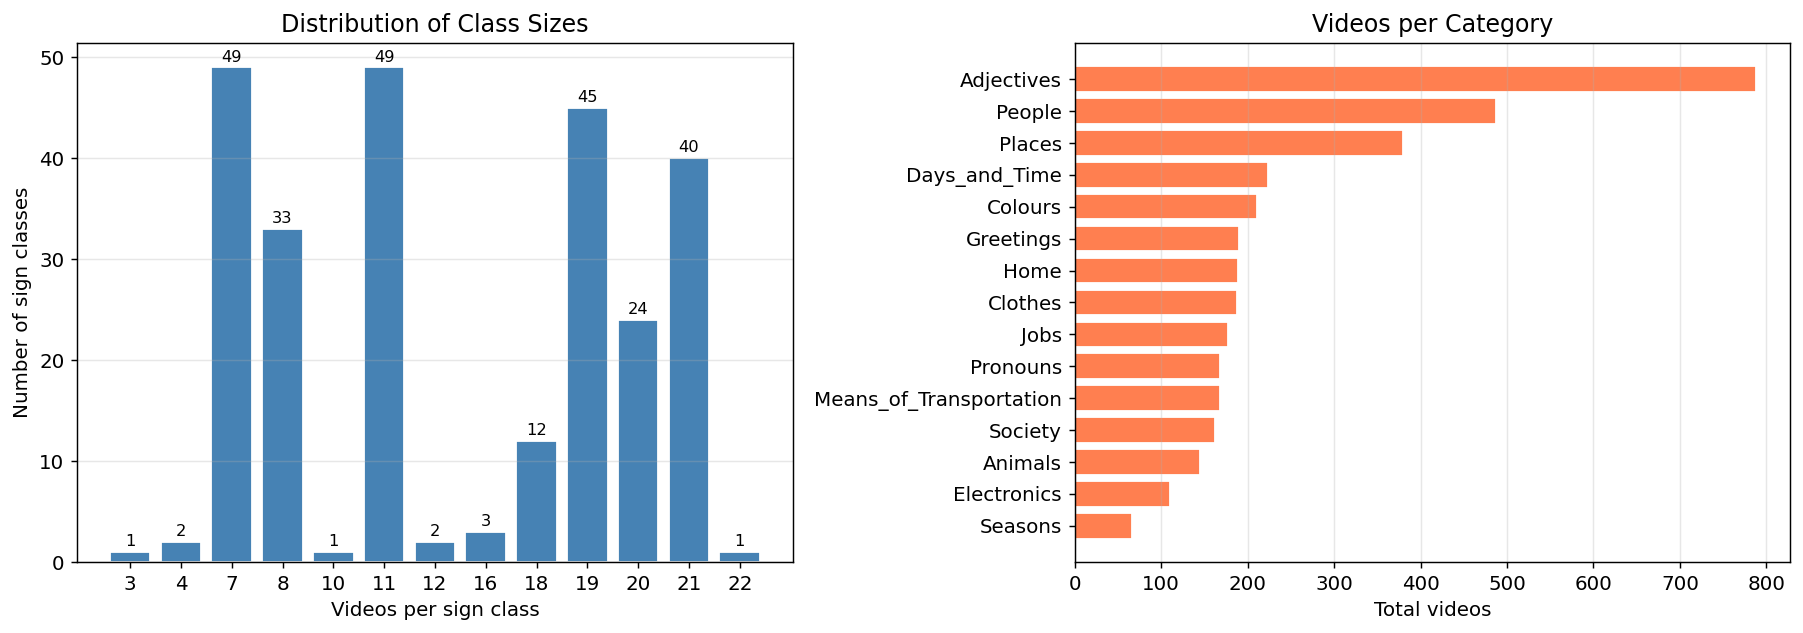

Total sign classes : 262
Min videos/class   : 3 ('81. Second')
Max videos/class   : 22 ('52. Good afternoon')
Mean videos/class  : 13.94
Classes with <14   : 137
Classes with >16   : 122


In [15]:
class_counts = meta['sign'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of counts (how many classes have 14, 15, 16 videos etc.)
ax = axes[0]
count_dist = class_counts.value_counts().sort_index()
ax.bar(count_dist.index.astype(str), count_dist.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Videos per sign class')
ax.set_ylabel('Number of sign classes')
ax.set_title('Distribution of Class Sizes')
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(ax.patches, count_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=9)

# Per-category mean count
ax2 = axes[1]
meta['category_clean'] = meta['category'].str.strip()
cat_counts = meta.groupby('category_clean')['sign'].count().sort_values(ascending=True)
bars = ax2.barh(cat_counts.index, cat_counts.values, color='coral', edgecolor='white')
ax2.set_xlabel('Total videos')
ax2.set_title('Videos per Category')
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / 'class_frequency.png', bbox_inches='tight')
plt.show()

print(f'Total sign classes : {len(class_counts)}')
print(f'Min videos/class   : {class_counts.min()} ({class_counts.idxmin()!r})')
print(f'Max videos/class   : {class_counts.max()} ({class_counts.idxmax()!r})')
print(f'Mean videos/class  : {class_counts.mean():.2f}')
print(f'Classes with <14   : {(class_counts < 14).sum()}')
print(f'Classes with >16   : {(class_counts > 16).sum()}')

## 3. Keypoint Quality Analysis

The MediaPipe Task API (HandLandmarker + PoseLandmarker) can fail to detect
hands in some frames due to fast motion, occlusion, or poor lighting.

**Validity note:** The overall joint validity across all 53 joints is high because
the 11 upper-body (pose) joints are nearly always detected (~99%). Hand joints
(42 of 53) are much less reliable — approximately **23% of frames have at least
one missing hand**, giving a hand-joint validity of ~77%.  Do not use the
pooled 95.9% figure; report hand and body validity separately.

### 3a. Per proxy-signer group breakdown

> **⚠ Signer ID status — investigation complete (June 2026):** Signer labels are
> confirmed not publicly available in any INCLUDE source — Zenodo folder structure,
> HuggingFace parquet, and AI4Bharat GitHub repo were all checked; none contain a
> signer-to-video mapping. The IDs used here are **recording-session proxy
> assignments** (videos sorted by MVI filename, ranks 0–14 within each sign class).
> The uneven per-group counts (387 down to 125, vs. ~243 expected) confirm these do
> **not** recover real signer identities. This chart is retained as a supplementary
> robustness probe only and must **not** be interpreted as a per-person dropout
> analysis or cited as cross-signer evidence.

### 3b. Per-category breakdown
Which sign categories are hardest for MediaPipe to track.

miss_left_raw not in metadata — computing from raw .npy files (this takes ~1 min)...
Done. Computed miss stats for 3652 videos.


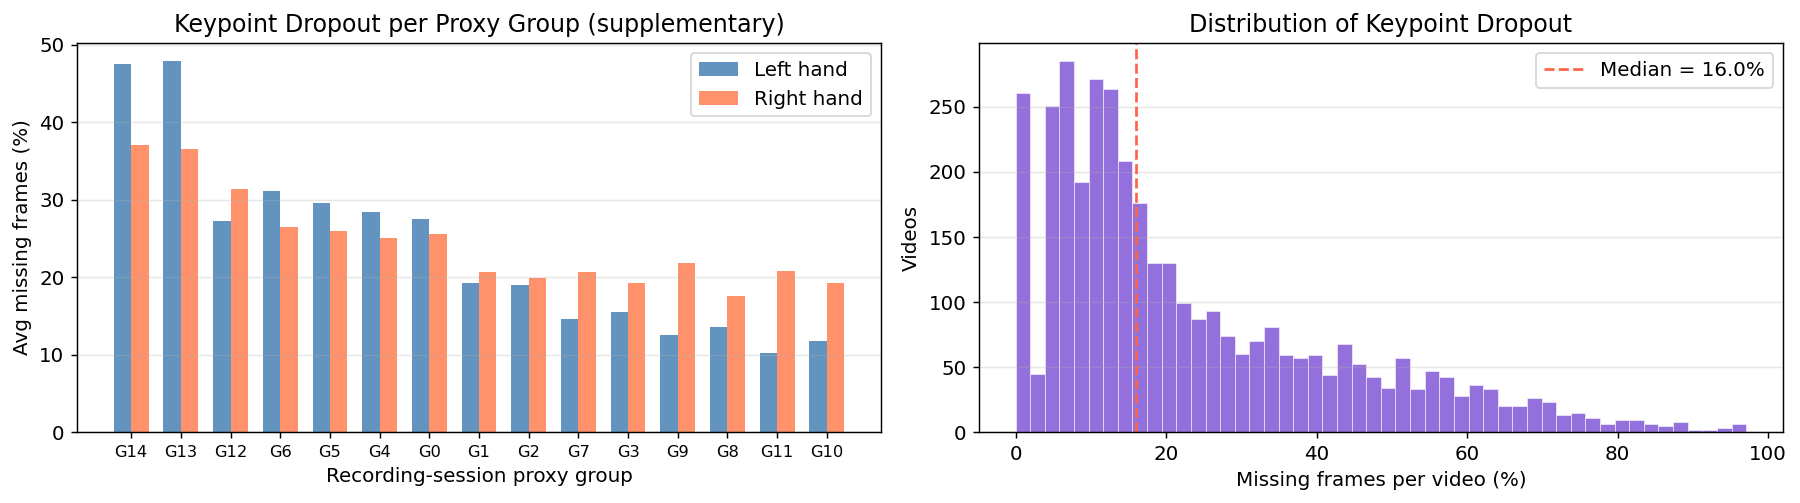

Per proxy-group keypoint dropout (avg %, sorted highest → lowest):
           miss_left_pct  miss_right_pct  miss_any_pct
signer_id                                             
14                  47.5            37.0          42.3
13                  47.8            36.5          42.2
12                  27.2            31.4          29.3
6                   31.1            26.5          28.8
5                   29.5            25.9          27.7
4                   28.5            25.0          26.7
0                   27.5            25.6          26.5
1                   19.2            20.6          19.9
2                   19.0            19.9          19.4
7                   14.6            20.6          17.6
3                   15.5            19.3          17.4
9                   12.6            21.8          17.2
8                   13.6            17.6          15.6
11                  10.3            20.7          15.5
10                  11.7            19.2          15.

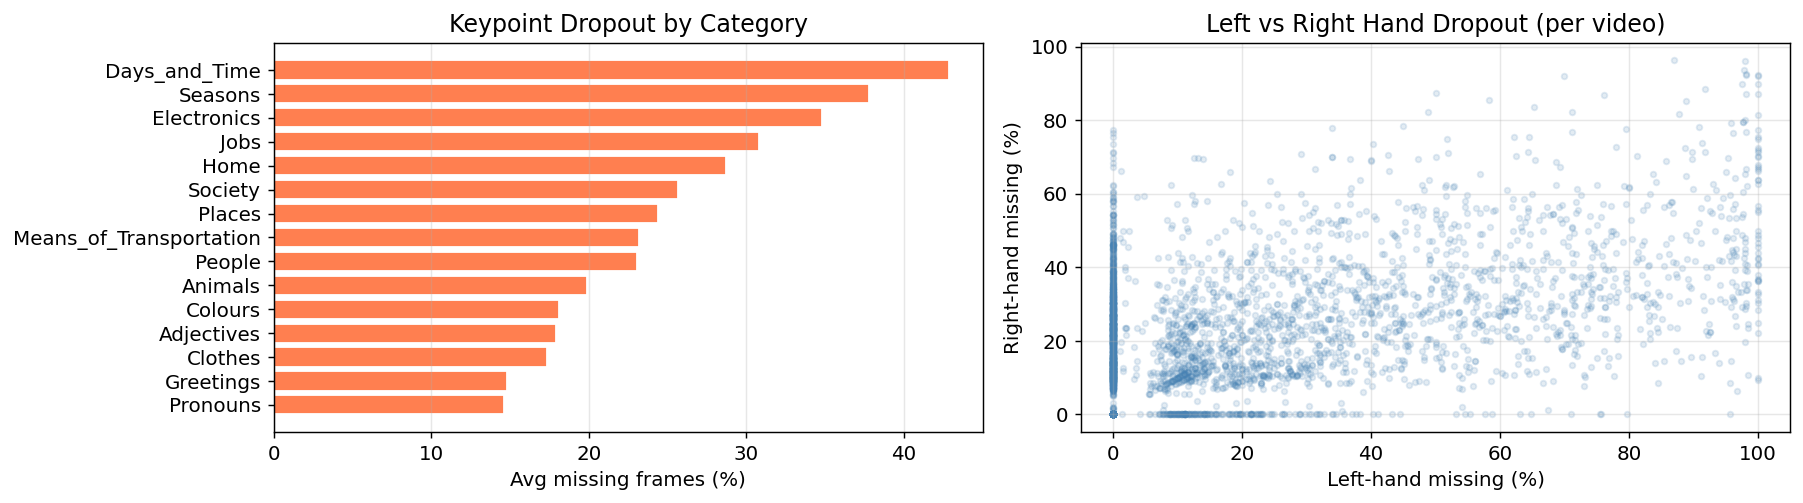


Mean missing (left)   : 22.9%
Mean missing (right)  : 23.5%
Videos with >25% miss : 1253
Proxy group with worst dropout : G14  (42.3%)
Proxy group with best  dropout : G10  (15.5%)


In [16]:
# Compute miss stats from raw .npy files if not present in metadata CSV
# (happens when NB01 ran with all files already extracted → status='skipped',
#  so miss_left_raw / miss_right_raw were never written to the CSV)
RAW_KP_DIR = DATA_DIR / 'raw_keypoints'

if 'miss_left_raw' not in meta.columns or meta['miss_left_raw'].isna().all():
    print("miss_left_raw not in metadata — computing from raw .npy files (this takes ~1 min)...")
    miss_left, miss_right = [], []
    for _, row in meta.iterrows():
        npy_path = RAW_KP_DIR / row['out_name']
        if not npy_path.exists():
            miss_left.append(np.nan)
            miss_right.append(np.nan)
            continue
        kps = np.load(str(npy_path))          # (T, 53, 3)
        # left hand joints: 0-20, right hand joints: 21-41
        ml = int(np.sum(np.all(kps[:, :21,  :] == 0, axis=(1, 2))))
        mr = int(np.sum(np.all(kps[:, 21:42, :] == 0, axis=(1, 2))))
        miss_left.append(ml)
        miss_right.append(mr)
    meta['miss_left_raw']  = miss_left
    meta['miss_right_raw'] = miss_right
    print(f"Done. Computed miss stats for {len(meta)} videos.")
else:
    print("miss_left_raw found in metadata CSV — using existing values.")

meta['miss_left_pct']  = meta['miss_left_raw']  / meta['n_frames'] * 100
meta['miss_right_pct'] = meta['miss_right_raw'] / meta['n_frames'] * 100
meta['miss_any_pct']   = (meta['miss_left_raw'] + meta['miss_right_raw']) / (2 * meta['n_frames']) * 100

# ── 3a. Per proxy-group ───────────────────────────────────────────────────────
signer_miss = (
    meta.dropna(subset=['signer_id'])
    .groupby('signer_id')[['miss_left_pct', 'miss_right_pct', 'miss_any_pct']]
    .mean()
    .sort_values('miss_any_pct', ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
x = np.arange(len(signer_miss))
w = 0.35
ax.bar(x - w/2, signer_miss['miss_left_pct'],  w, label='Left hand',  color='steelblue',   alpha=0.85)
ax.bar(x + w/2, signer_miss['miss_right_pct'], w, label='Right hand', color='coral',        alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([f'G{int(s)}' for s in signer_miss.index], fontsize=9)
ax.set_xlabel('Recording-session proxy group')
ax.set_ylabel('Avg missing frames (%)')
ax.set_title('Keypoint Dropout per Proxy Group (supplementary)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Overall dropout distribution
ax2 = axes[1]
ax2.hist(meta['miss_any_pct'], bins=50, color='mediumpurple', edgecolor='white', linewidth=0.3)
ax2.axvline(meta['miss_any_pct'].median(), color='tomato', linestyle='--',
            label=f"Median = {meta['miss_any_pct'].median():.1f}%")
ax2.set_xlabel('Missing frames per video (%)')
ax2.set_ylabel('Videos')
ax2.set_title('Distribution of Keypoint Dropout')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / 'keypoint_quality_per_proxy_group.png', bbox_inches='tight')
plt.show()

print('Per proxy-group keypoint dropout (avg %, sorted highest → lowest):')
print(signer_miss.round(1).to_string())

# ── 3b. Per-category ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
cat_miss = meta.groupby('category_clean')['miss_any_pct'].mean().sort_values(ascending=True)
ax.barh(cat_miss.index, cat_miss.values, color='coral', edgecolor='white')
ax.set_xlabel('Avg missing frames (%)')
ax.set_title('Keypoint Dropout by Category')
ax.grid(axis='x', alpha=0.3)

ax2 = axes[1]
ax2.scatter(meta['miss_left_pct'], meta['miss_right_pct'],
            alpha=0.15, s=10, color='steelblue')
ax2.set_xlabel('Left-hand missing (%)')
ax2.set_ylabel('Right-hand missing (%)')
ax2.set_title('Left vs Right Hand Dropout (per video)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(EDA_DIR / 'keypoint_quality_by_category.png', bbox_inches='tight')
plt.show()

print(f"\nMean missing (left)   : {meta['miss_left_pct'].mean():.1f}%")
print(f"Mean missing (right)  : {meta['miss_right_pct'].mean():.1f}%")
print(f"Videos with >25% miss : {(meta['miss_any_pct'] > 25).sum()}")
print(f"Proxy group with worst dropout : G{int(signer_miss.index[0])}  ({signer_miss.iloc[0]['miss_any_pct']:.1f}%)")
print(f"Proxy group with best  dropout : G{int(signer_miss.index[-1])}  ({signer_miss.iloc[-1]['miss_any_pct']:.1f}%)")

## 4. t-SNE of Mean Keypoint Features — Per Class

The roadmap (§4.3 Task 5) asks for t-SNE **per class**.

Strategy: compute the **class centroid** in feature space (mean of all training
samples for that class → one 159-D vector per class), then run t-SNE on the 262
centroids. Each point in the plot represents one sign class, coloured by its
category and labelled with the sign name. This gives a clean per-class view of
which signs cluster together and which are likely to be confused.

In [17]:
X_train = np.load(str(PROC_DIR / 'X_sd_train.npy'))   # (N, T, V, C)
y_train = np.load(str(PROC_DIR / 'y_sd_train.npy'))   # (N,)

with open(PROC_DIR / 'label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print(f'Training set : {X_train.shape}  |  {len(np.unique(y_train))} classes')

# ── Compute per-class centroids in flattened mean-feature space ───────────────
# (N, T, V, C) → mean over T → (N, V*C)
X_feat = X_train.mean(axis=1).reshape(len(X_train), -1)   # (N, 159)

unique_classes = np.unique(y_train)
class_centroids = np.stack([X_feat[y_train == c].mean(axis=0)
                             for c in unique_classes])      # (262, 159)
class_names = le.inverse_transform(unique_classes)          # sign name strings

# Attach category to each class for colouring
sign_to_cat = dict(zip(meta['sign'], meta['category_clean']))
class_cats  = np.array([sign_to_cat.get(n, 'Unknown') for n in class_names])

print(f'Class centroids shape : {class_centroids.shape}')

Training set : (2462, 64, 53, 3)  |  262 classes
Class centroids shape : (262, 159)


In [18]:
print('Running t-SNE on 262 class centroids (fast — seconds not minutes)...')
tsne = TSNE(
    n_components=2,
    perplexity=30,          # lower perplexity suits small N (262 points)
    learning_rate='auto',
    init='pca',
    n_iter=1500,
    random_state=42,
    verbose=0,
)
centroids_2d = tsne.fit_transform(class_centroids)   # (262, 2)
print(f't-SNE done. KL divergence: {tsne.kl_divergence_:.4f}')

Running t-SNE on 262 class centroids (fast — seconds not minutes)...
t-SNE done. KL divergence: 0.3993


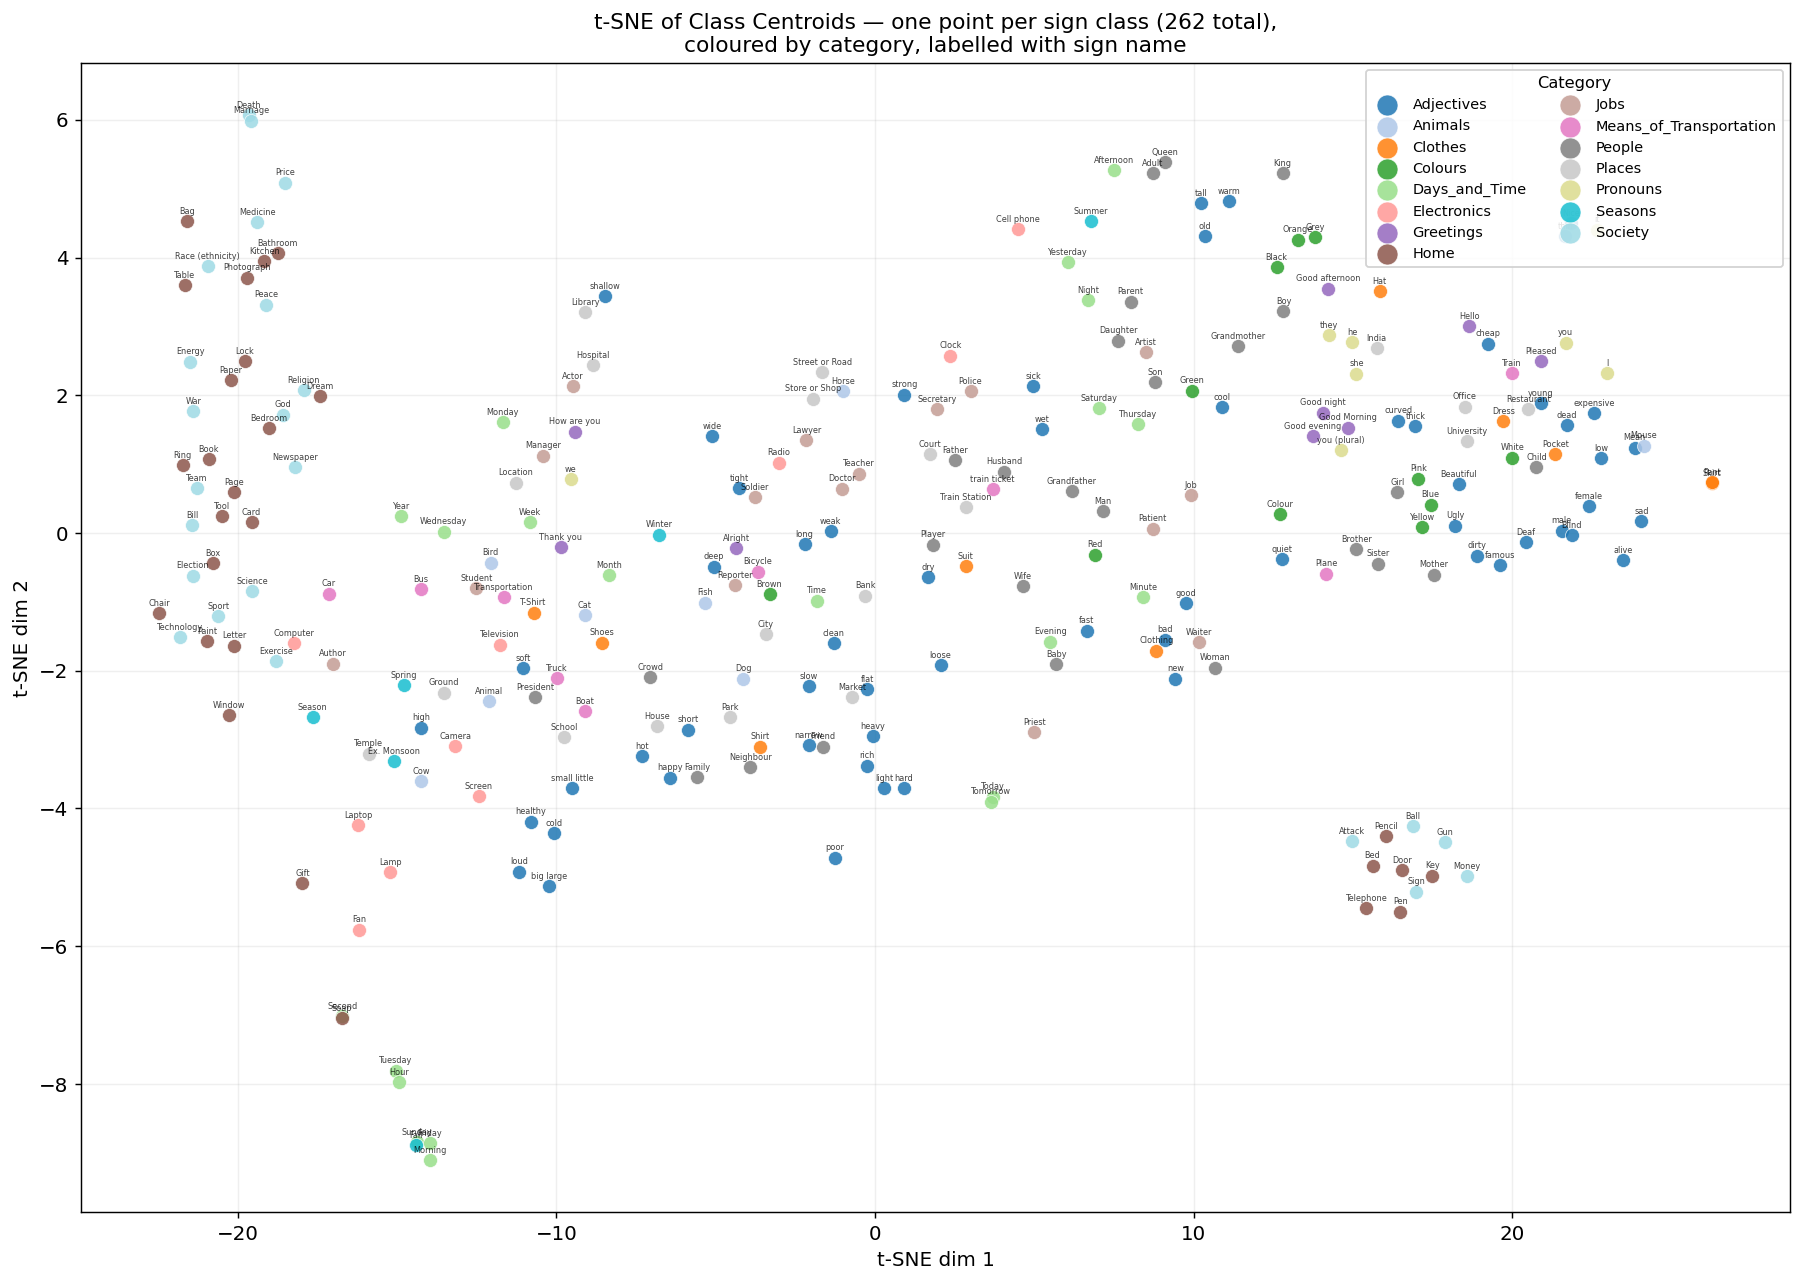

Saved: tsne_per_class.png


In [19]:
unique_cats = sorted(set(class_cats))
n_cats      = len(unique_cats)
palette     = cm.get_cmap('tab20', n_cats)
cat_to_int  = {c: i for i, c in enumerate(unique_cats)}

fig, ax = plt.subplots(figsize=(14, 10))

for ci, cat in enumerate(unique_cats):
    mask = class_cats == cat
    ax.scatter(
        centroids_2d[mask, 0], centroids_2d[mask, 1],
        s=60, alpha=0.85,
        color=palette(ci),
        label=cat,
        linewidths=0.4,
        edgecolors='white',
        zorder=3,
    )

# Label every class with its sign name (stripped of the numbering prefix)
import re
for i, name in enumerate(class_names):
    # Strip leading "N. " pattern for readability (e.g. "1. loud" → "loud")
    label = re.sub(r'^\d+\.\s*', '', str(name))
    ax.annotate(
        label,
        (centroids_2d[i, 0], centroids_2d[i, 1]),
        fontsize=4.5,
        alpha=0.75,
        ha='center',
        va='bottom',
        xytext=(0, 3),
        textcoords='offset points',
    )

ax.legend(
    loc='upper right',
    fontsize=8,
    markerscale=1.5,
    ncol=2,
    framealpha=0.85,
    title='Category',
    title_fontsize=9,
)
ax.set_title(
    't-SNE of Class Centroids — one point per sign class (262 total),\n'
    'coloured by category, labelled with sign name',
    fontsize=12,
)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(EDA_DIR / 'tsne_per_class.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: tsne_per_class.png')

## 5. SD / SI Split Summary

In [20]:
X_val  = np.load(str(PROC_DIR / 'X_sd_val.npy'))
X_test = np.load(str(PROC_DIR / 'X_sd_test.npy'))

print('=== Signer-Dependent (SD) splits — main benchmark ===')
print(f'  Train : {X_train.shape[0]:>5} samples  shape {X_train.shape}')
print(f'  Val   : {X_val.shape[0]:>5} samples  shape {X_val.shape}')
print(f'  Test  : {X_test.shape[0]:>5} samples  shape {X_test.shape}')
print(f'  Total : {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}  '
      f'(= 3,652 unique videos, fully deduplicated)')
print()

with open(PROC_DIR / 'si_splits.pkl', 'rb') as f:
    si = pickle.load(f)

print('=== Recording-Session Proxy — supplementary probe only ===')
print('    NOT signer-independent: signer labels confirmed not publicly available.')
print('    Folds use rank-by-MVI proxy IDs (do not correspond to real individuals).')
print('    Do NOT cite as cross-signer results in any reported finding.')
print()
for fold in si:
    print(f"  Fold {fold['fold']}  proxy-group: {fold['held_out']}  "
          f"train={fold['X_train'].shape[0]}  test={fold['X_test'].shape[0]}")

print()
print('EDA complete. Figures saved to data/eda/')

=== Signer-Dependent (SD) splits — main benchmark ===
  Train :  2462 samples  shape (2462, 64, 53, 3)
  Val   :   332 samples  shape (332, 64, 53, 3)
  Test  :   858 samples  shape (858, 64, 53, 3)
  Total : 3652  (= 3,652 unique videos, fully deduplicated)

=== Recording-Session Proxy — supplementary probe only ===
    NOT signer-independent: signer labels confirmed not publicly available.
    Folds use rank-by-MVI proxy IDs (do not correspond to real individuals).
    Do NOT cite as cross-signer results in any reported finding.

  Fold 0  proxy-group: [0, 1, 2]  train=2497  test=1155
  Fold 1  proxy-group: [3, 4, 5]  train=2657  test=995
  Fold 2  proxy-group: [6, 7, 8]  train=3005  test=647
  Fold 3  proxy-group: [9, 10, 11]  train=3172  test=480
  Fold 4  proxy-group: [12, 13, 14]  train=3277  test=375

EDA complete. Figures saved to data/eda/
